# EDA: Payment Transactions Dataset

In [ ]:
import pandas as pd
import numpy as np
from plotnine import *

In [ ]:
df = pd.read_csv('test_task.csv')

## 1. Загальний огляд датасету

In [ ]:
df.shape

(463521, 17)

In [ ]:
df.head()

,user_id,transaction_id,reference_transaction_id,project,plan_id,transaction_type,status,decline_code,transaction_time,psp_name,payment_method_type,card_brand,card_type,card_level,country,amount_usd,fee_usd
0,u_0001f8a7ee92,t_5cd8aa890853,NaN,Nexora,p_3934,SALE,SUCCESS,NaN,2025-09-15 02:21:44.909000,Global Payments,card,VISA,CREDIT,CLASSIC,US,30.58,0.4234
1,u_0001f8a7ee92,t_a9d478f87372,t_5cd8aa890853,Nexora,p_3934,CAPTURE,SUCCESS,NaN,2025-09-19 20:22:12.437000,Global Payments,card,VISA,CREDIT,CLASSIC,US,0.00,1.1781
2,u_0001f8a7ee92,t_f43e08a529ec,NaN,Nexora,p_3934,SALE,DECLINED,4670.0,2025-09-23 20:20:26.408000,Fiserv,card,VISA,CREDIT,CLASSIC,US,0.00,0.6051
3,u_0001f8a7ee92,t_d1439d0cf4be,NaN,Nexora,p_3934,SALE,DECLINED,4670.0,2025-10-19 15:21:50.706000,Global Payments,card,VISA,CREDIT,CLASSIC,US,0.00,0.4222
4,u_0001f8a7ee92,t_1503c7d7d71a,NaN,Nexora,p_3934,SALE,DECLINED,4670.0,2025-10-20 10:33:51.398000,Global Payments,card,VISA,CREDIT,CLASSIC,US,0.00,0.4217


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463521 entries, 0 to 463520
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   463239 non-null  object 
 1   transaction_id            463521 non-null  object 
 2   reference_transaction_id  116264 non-null  object 
 3   project                   463521 non-null  object 
 4   plan_id                   462588 non-null  object 
 5   transaction_type          463521 non-null  object 
 6   status                    463521 non-null  object 
 7   decline_code              139225 non-null  float64
 8   transaction_time          463521 non-null  object 
 9   psp_name                  463521 non-null  object 
 10  payment_method_type       459833 non-null  object 
 11  card_brand                453801 non-null  object 
 12  card_type                 434641 non-null  object 
 13  card_level                414152 non-null  o

In [ ]:
df.describe()

,decline_code,amount_usd,fee_usd
count,139225.000000,463521.000000,463521.00000
mean,5499.071819,20.436060,1.04847
std,2285.438001,31.552938,2.79007
min,31.000000,-145.120000,-2.86080
25%,4670.000000,0.000000,0.08570
50%,4670.000000,0.000000,0.42290
75%,7322.000000,45.880000,1.41100
max,9966.000000,145.120000,63.12250


 ## 2. Дублікати та пропуски (загальний огляд)

In [ ]:
df[df.duplicated()]

,user_id,transaction_id,reference_transaction_id,project,plan_id,transaction_type,status,decline_code,transaction_time,psp_name,payment_method_type,card_brand,card_type,card_level,country,amount_usd,fee_usd


In [ ]:
df.isna().sum()

,0
user_id,282
transaction_id,0
reference_transaction_id,347257
project,0
plan_id,933
transaction_type,0
status,0
decline_code,324296
transaction_time,0
psp_name,0


In [ ]:
df.isna().sum().sum()

np.int64(772419)

## 3. Пояснення пропусків по колонках

In [ ]:
df[df['plan_id'].isna()]['transaction_type'].value_counts()

,count
transaction_type,
SALE,464
ALERT,230
CAPTURE,133
REFUND,91
VOID,10
CHARGEBACK,5


Ще однією особливістю даних є те, що на відміну від пропусків user_id (які торкаються лише ALERT/REFUND/CHARGEBACK), пропуски plan_id зачіпають і SALE (464 випадки). Тобто частина реальних платежів не має вказаного тарифного плану

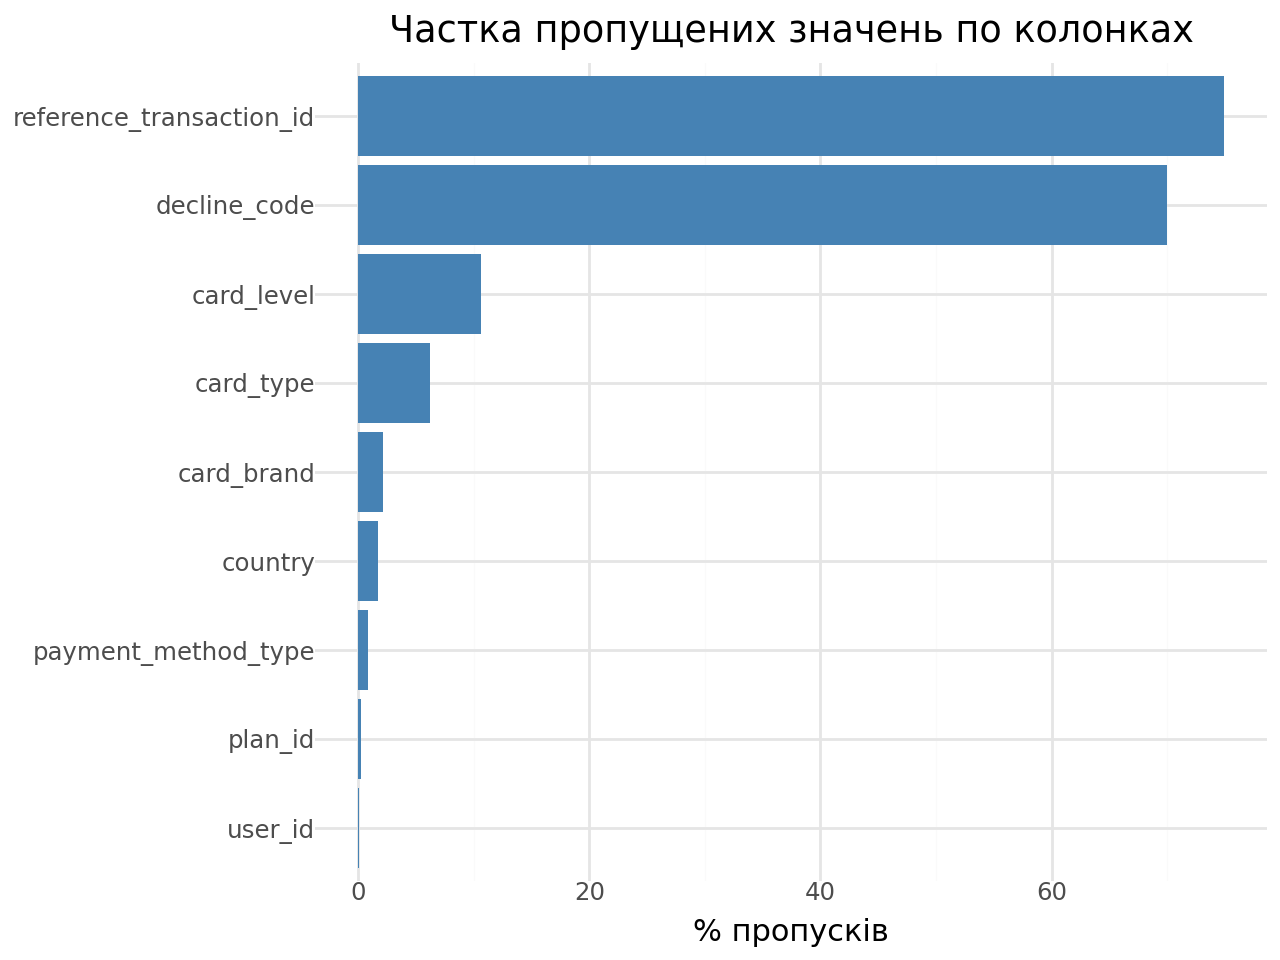

In [ ]:
missing_df = (df.isna().sum() / len(df) * 100).reset_index()
missing_df.columns = ['column', 'pct_missing']
missing_df = missing_df[missing_df['pct_missing'] > 0].sort_values('pct_missing')
missing_df['column'] = pd.Categorical(missing_df['column'], categories=missing_df['column'], ordered=True)

(
    ggplot(missing_df, aes(x='column', y='pct_missing'))
    + geom_col(fill='steelblue')
    + coord_flip()
    + labs(title='Частка пропущених значень по колонках', x='', y='% пропусків')
    + theme_minimal()
)

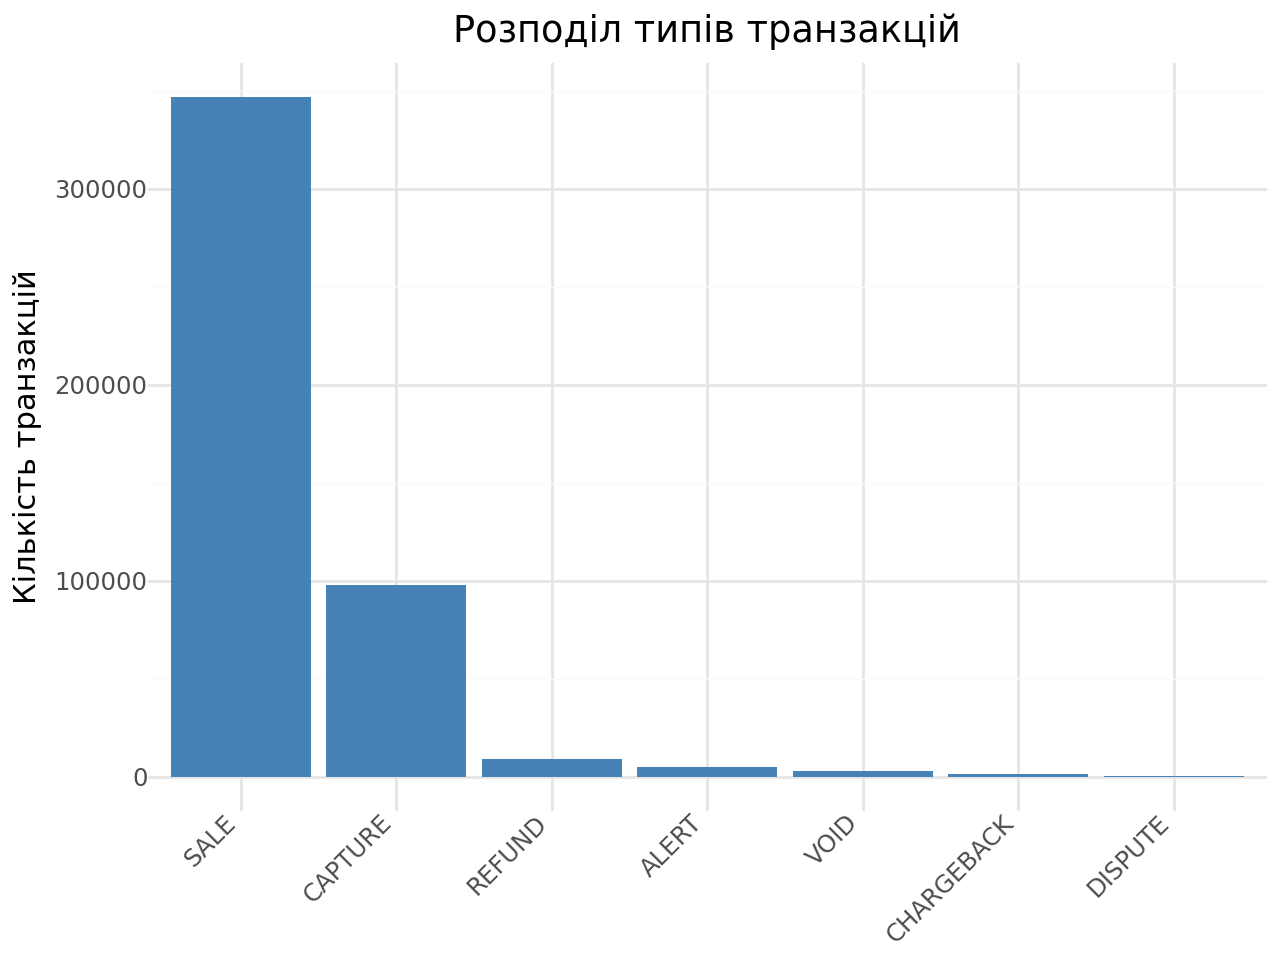

In [ ]:
type_counts = df['transaction_type'].value_counts().reset_index()
type_counts.columns = ['transaction_type', 'count']
type_counts['transaction_type'] = pd.Categorical(
    type_counts['transaction_type'],
    categories=type_counts.sort_values('count', ascending=False)['transaction_type'],
    ordered=True
)

(
    ggplot(type_counts, aes(x='transaction_type', y='count'))
    + geom_col(fill='steelblue')
    + labs(title='Розподіл типів транзакцій', x='', y='Кількість транзакцій')
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

In [ ]:
df[df['user_id'].isna()]['transaction_type'].value_counts()

,count
transaction_type,
ALERT,221
REFUND,56
CHARGEBACK,5


Усі 282 рядки з відсутнім user_id належать до adjustment-транзакцій

In [ ]:
df.groupby('status')['decline_code'].count() / df.groupby('status')['decline_code'].size()

,decline_code
status,
DECLINED,0.996457
LOST,0.000000
SUCCESS,0.031166


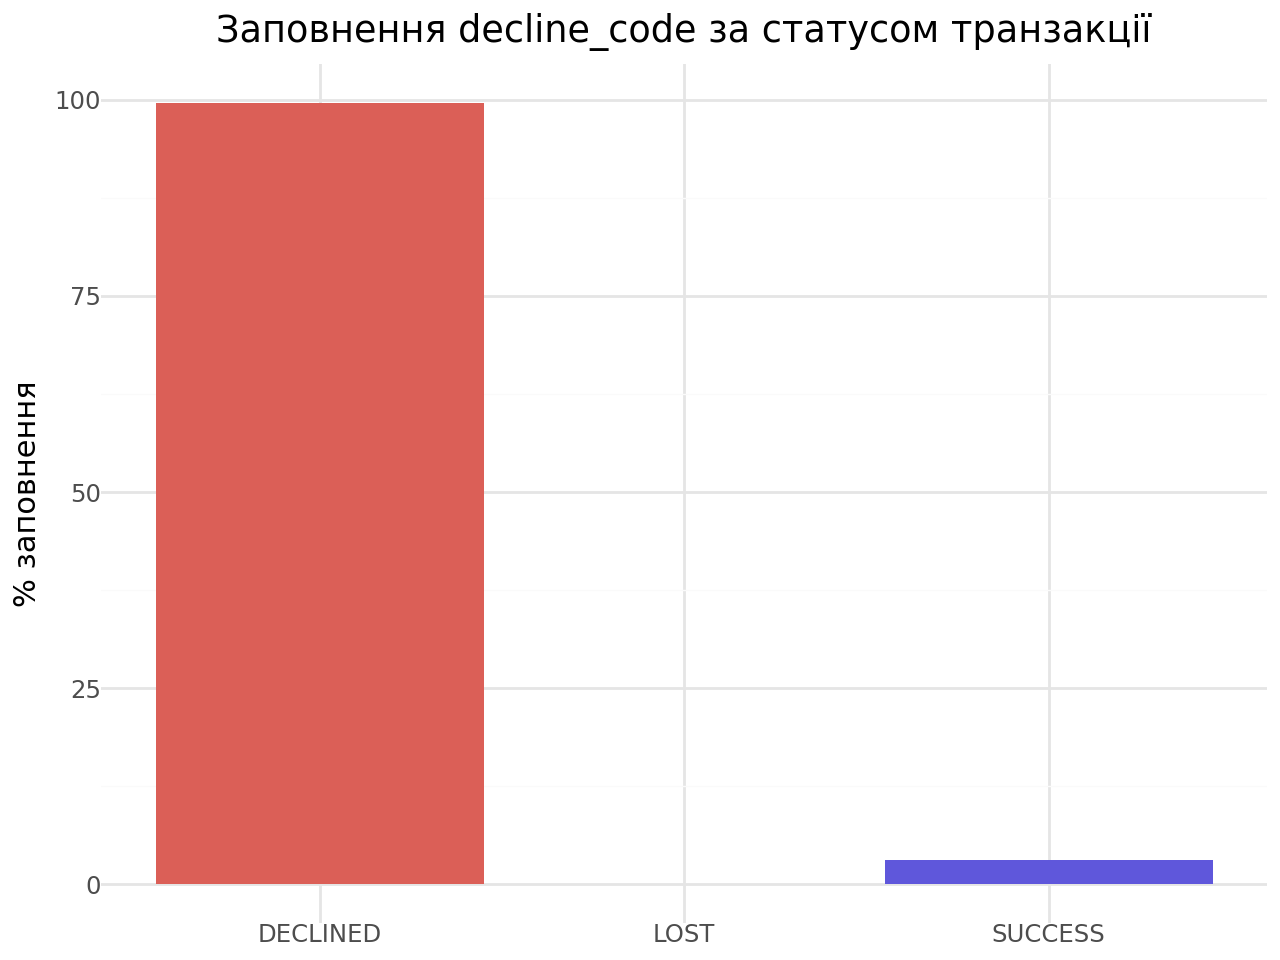

In [ ]:
fill_rate = df.groupby('status')['decline_code'].count() / df.groupby('status')['decline_code'].size() * 100
fill_df = fill_rate.reset_index()
fill_df.columns = ['status', 'pct_filled']

(
    ggplot(fill_df, aes(x='status', y='pct_filled', fill='status'))
    + geom_col(show_legend=False)
    + labs(title='Заповнення decline_code за статусом транзакції', x='', y='% заповнення')
    + theme_minimal()
)


In [ ]:
df[df['status']=='LOST']['transaction_type'].value_counts()

,count
transaction_type,
DISPUTE,98
CHARGEBACK,4


Статус LOST зустрічається виключно в DISPUTE і CHARGEBACK

In [ ]:
df.groupby('transaction_type')['reference_transaction_id'].count() / df.groupby('transaction_type')['reference_transaction_id'].size()

,reference_transaction_id
transaction_type,
ALERT,0.956359
CAPTURE,1.000000
CHARGEBACK,0.995964
DISPUTE,1.000000
REFUND,1.000000
SALE,0.000000
VOID,1.000000


Підтвердження, що reference_transaction_id використовується для зв'язку дочірніх транзакцій (adjustments та CAPTURE) з батьківською SALE. Cамі SALE не містять reference_transaction_id

In [ ]:
df[(df['transaction_type']=='ALERT') & (df['reference_transaction_id'].isna())]

,user_id,transaction_id,reference_transaction_id,project,plan_id,transaction_type,status,decline_code,transaction_time,psp_name,payment_method_type,card_brand,card_type,card_level,country,amount_usd,fee_usd
463239,NaN,t_8e910e6b5a2a,NaN,Nexora,NaN,ALERT,DECLINED,NaN,2025-02-01 09:00:00.000000,HSBC,NaN,MASTERCARD,NaN,NaN,NaN,0.0,26.9953
463240,NaN,t_241818b0ab23,NaN,Nexora,NaN,ALERT,DECLINED,NaN,2025-03-04 05:00:00.000000,HSBC,NaN,MASTERCARD,NaN,NaN,NaN,0.0,26.9772
463241,NaN,t_1c5fd0f9cea2,NaN,Nexora,NaN,ALERT,DECLINED,NaN,2025-03-10 14:00:00.000000,HSBC,NaN,VISA,NaN,NaN,NaN,0.0,28.3815
463242,NaN,t_dcdb735dc593,NaN,Nexora,NaN,ALERT,DECLINED,NaN,2025-03-13 14:00:00.000000,HSBC,NaN,VISA,NaN,NaN,NaN,0.0,28.3916
463243,NaN,t_d6f7320dded9,NaN,Nexora,NaN,ALERT,DECLINED,5199.0,2025-03-14 15:00:00.000000,Fiserv,NaN,MASTERCARD,NaN,NaN,NaN,0.0,28.3604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463509,NaN,t_390062d5ac64,NaN,Nexora,NaN,ALERT,DECLINED,NaN,2025-11-22 11:00:00.000000,JPMorgan,NaN,VISA,NaN,NaN,NaN,0.0,21.0743
463511,NaN,t_a8138c70dd92,NaN,Nexora,NaN,ALERT,DECLINED,8863.0,2025-11-24 11:00:00.000000,HSBC,NaN,VISA,NaN,NaN,NaN,0.0,21.2359
463514,NaN,t_b557b13c9b7d,NaN,Nexora,NaN,ALERT,DECLINED,NaN,2025-11-28 06:00:00.000000,HSBC,NaN,MASTERCARD,NaN,NaN,NaN,0.0,21.1790
463516,NaN,t_d6af317ca758,NaN,Nexora,NaN,ALERT,DECLINED,6969.0,2025-12-01 14:00:00.000000,Fiserv,NaN,VISA,NaN,NaN,NaN,0.0,57.5762


In [ ]:
df.groupby('payment_method_type')[['card_brand','card_type','card_level']].count() / df.groupby('payment_method_type').size().values.reshape(-1,1)

,card_brand,card_type,card_level
payment_method_type,,,
apple_pay,0.990709,0.931994,0.871512
card,0.997363,0.995781,0.982336
google_pay,0.995349,0.977996,0.964005
paypal,0.000000,0.000000,0.000000


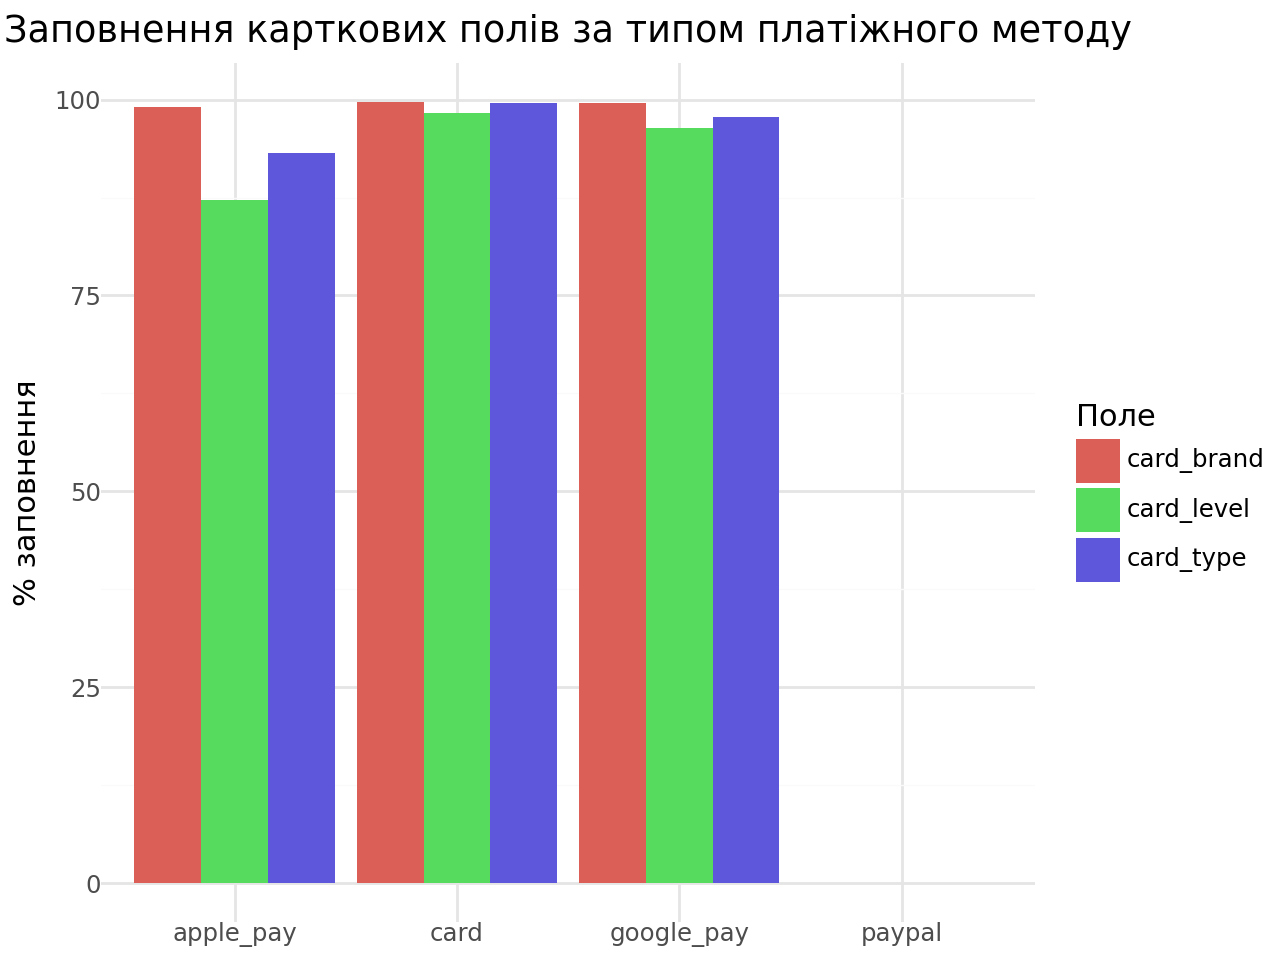

In [ ]:
tmp = df[['payment_method_type','card_brand','card_type','card_level']].copy()
tmp['card_brand'] = tmp['card_brand'].notna()
tmp['card_type'] = tmp['card_type'].notna()
tmp['card_level'] = tmp['card_level'].notna()

fill_long = tmp.groupby('payment_method_type')[['card_brand','card_type','card_level']].mean().reset_index()
fill_long = fill_long.melt(id_vars='payment_method_type', var_name='field', value_name='pct_filled')
fill_long['pct_filled'] = fill_long['pct_filled'] * 100

(
    ggplot(fill_long, aes(x='payment_method_type', y='pct_filled', fill='field'))
    + geom_col(position='dodge')
    + labs(title='Заповнення карткових полів за типом платіжного методу', x='', y='% заповнення', fill='Поле')
    + theme_minimal()
)

Пропуски в card_brand/card_type/card_level логічно пояснюються payment_method_type: для paypal ці поля пропущені на 100% (PayPal не є карткою за визначенням)

In [ ]:
df.groupby('psp_name')['country'].count() / df.groupby('psp_name')['country'].size()

,country
psp_name,
FIS,0.998315
Fiserv,0.981339
Fluxline Inc,1.000000
Global Payments,0.973217
HSBC,0.982895
JPMorgan,0.995712
Vertex Ltd,1.000000


Заповнення country рівномірне по всіх платіжних провайдерах

## 4. Розподіл типів транзакцій

In [ ]:
df['transaction_type'].value_counts()

,count
transaction_type,
SALE,347031
CAPTURE,97881
REFUND,9097
ALERT,5064
VOID,3111
CHARGEBACK,1239
DISPUTE,98


Отож, SALE домінує у нашому датасеті

## 5. Часовий діапазон

In [ ]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
print(df['transaction_time'].min(), df['transaction_time'].max())

2024-12-25 08:31:24 2025-12-09 19:30:56.222000


Дані охоплюють період з 25.12.2024 по 09.12.2025. Майже рік

## 6. Аналіз сум і комісій

In [ ]:
df[df['transaction_type'].isin(['REFUND','CHARGEBACK','VOID'])]['amount_usd'].describe()

,amount_usd
count,13447.000000
mean,-50.718643
std,24.730582
min,-145.120000
25%,-61.180000
50%,-59.590000
75%,-30.580000
max,0.000000


In [ ]:
df.groupby('transaction_type')['amount_usd'].agg(['min','max','mean'])

,min,max,mean
transaction_type,,,
ALERT,-145.12,0.00,-52.095831
CAPTURE,0.00,0.00,0.000000
CHARGEBACK,-145.12,0.00,-55.719443
DISPUTE,-76.48,-7.63,-37.101633
REFUND,-145.12,0.00,-56.650957
SALE,0.00,145.12,30.031916
VOID,-76.48,0.00,-31.380084


Підтверджено, REFUND, CHARGEBACK, VOID, DISPUTE, ALERT мають amount_usd <= 0

CAPTURE завжди має amount_usd = 0

Тільки SALE має додатні значення

In [ ]:
df.groupby('transaction_type')['fee_usd'].agg(['min','max','mean'])

,min,max,mean
transaction_type,,,
ALERT,0.0000,63.1225,22.375986
CAPTURE,0.0000,2.8243,0.310108
CHARGEBACK,-2.8608,43.2000,20.454241
DISPUTE,-2.8608,0.0000,-0.591184
REFUND,0.0000,0.2771,0.097414
SALE,0.0000,5.5677,0.910108
VOID,0.0000,0.2771,0.101490


CAPTURE, попри нульову суму, має ненульову комісію

ALERT вирізняється найвищими комісіями

In [ ]:
alert_counts = df[(df['transaction_type']=='ALERT') & (df['reference_transaction_id'].notna())] \
    .groupby('reference_transaction_id').size()

alert_counts.value_counts().sort_index()

,count
1,4685
2,74
3,1
7,1


In [ ]:
alert_counts.sort_values(ascending=False).head(5)

,0
reference_transaction_id,
t_ed93eec7cafd,7
t_44374ee33c31,3
t_c6ed67c12ff6,2
t_7952dea69cd6,2
t_59335859dbc4,2


In [ ]:
worst_id = alert_counts.idxmax()
df[(df['transaction_id']==worst_id) | (df['reference_transaction_id']==worst_id)]

,user_id,transaction_id,reference_transaction_id,project,plan_id,transaction_type,status,decline_code,transaction_time,psp_name,payment_method_type,card_brand,card_type,card_level,country,amount_usd,fee_usd
208751,u_72eea20deca1,t_ed93eec7cafd,NaN,Nexora,p_ba54,SALE,SUCCESS,NaN,2025-07-09 22:32:11.827,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,45.88,1.2191
208752,u_72eea20deca1,t_da45b93d5b70,t_ed93eec7cafd,Nexora,p_ba54,CAPTURE,SUCCESS,NaN,2025-07-15 14:32:31.903,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,0.0169
208753,u_72eea20deca1,t_bbf478ba33cb,t_ed93eec7cafd,Nexora,p_ba54,ALERT,DECLINED,NaN,2025-09-12 16:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575
208754,u_72eea20deca1,t_2b6c3ee3cfe9,t_ed93eec7cafd,Nexora,p_ba54,ALERT,DECLINED,NaN,2025-09-12 20:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575
208755,u_72eea20deca1,t_e1f96b7306ae,t_ed93eec7cafd,Nexora,p_ba54,ALERT,DECLINED,NaN,2025-09-12 20:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575
208756,u_72eea20deca1,t_47abe29b1d92,t_ed93eec7cafd,Nexora,p_ba54,ALERT,DECLINED,NaN,2025-09-18 23:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575
208757,u_72eea20deca1,t_61d5d185d0b7,t_ed93eec7cafd,Nexora,p_ba54,ALERT,DECLINED,NaN,2025-09-20 10:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575
208758,u_72eea20deca1,t_5be47bd3b244,t_ed93eec7cafd,Nexora,p_ba54,ALERT,SUCCESS,NaN,2025-09-21 07:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575
208759,u_72eea20deca1,t_b6de9f579830,t_ed93eec7cafd,Nexora,p_ba54,ALERT,DECLINED,NaN,2025-09-23 17:00:00.000,HSBC,google_pay,VISA,CREDIT,CLASSIC,US,0.00,21.6575


Тут я вирішила детальніше дослідити ALERT.  У результаті, виявлено 1 outlier із 7 ALERT, розтягнуті на 2 тижні. Тому це значення значуще може впливати на net_revenue саме для цієї транзакції

## 7. Описова статистика

In [ ]:
df[['amount_usd','fee_usd']].describe()

,amount_usd,fee_usd
count,463521.000000,463521.00000
mean,20.436060,1.04847
std,31.552938,2.79007
min,-145.120000,-2.86080
25%,0.000000,0.08570
50%,0.000000,0.42290
75%,45.880000,1.41100
max,145.120000,63.12250


Чи є fee_usd більший за сам amount_usd (підозріло)

In [ ]:
df[(df['transaction_type']=='SALE') & (df['fee_usd'] > df['amount_usd']) & (df['amount_usd'] > 0)]

,user_id,transaction_id,reference_transaction_id,project,plan_id,transaction_type,status,decline_code,transaction_time,psp_name,payment_method_type,card_brand,card_type,card_level,country,amount_usd,fee_usd


Можемо побачити, що результатів немає, тому все ок

Чи є негативний amount_usd там, де не мало б бути (тобто в SALE)

In [ ]:
df[(df['transaction_type']=='SALE') & (df['amount_usd'] < 0)]

,user_id,transaction_id,reference_transaction_id,project,plan_id,transaction_type,status,decline_code,transaction_time,psp_name,payment_method_type,card_brand,card_type,card_level,country,amount_usd,fee_usd


Можемо побачити, що результатів немає, тому все ок

Екстремальні значення fee_usd

In [ ]:
df['fee_usd'].nlargest(5)
df['fee_usd'].nsmallest(5)

,fee_usd
295654,-2.8608
395964,-2.8608
435833,-2.8608
55326,-2.3904
288701,-2.3904


Екстремальні значення fee_usd були додатково перевірені. У результаті, очевидних аномальних значень, які потребують очищення, не виявлено

In [ ]:
df[['amount_usd','fee_usd']].agg(['mean','std','min','max'])

,amount_usd,fee_usd
mean,20.436060,1.04847
std,31.552938,2.79007
min,-145.120000,-2.86080
max,145.120000,63.12250


В обох полях std перевищує mean, що вказує на сильно асиметричний розподіл. Це є очікувано, оскільки датасет змішує різні типи транзакцій

## 8. Univariate Analysis

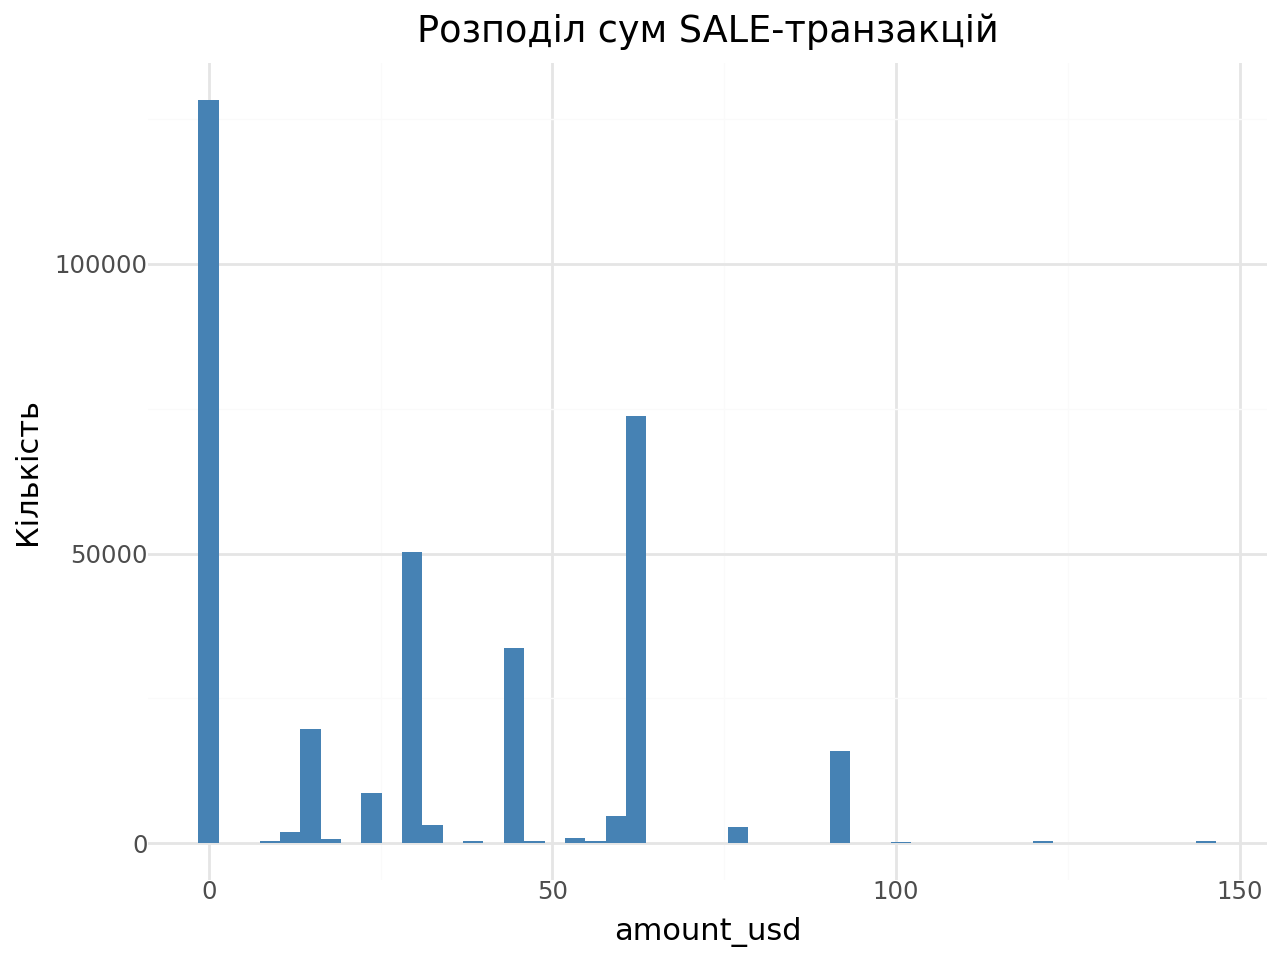

In [ ]:
sale_amounts = df[df['transaction_type']=='SALE']

(
    ggplot(sale_amounts, aes(x='amount_usd'))
    + geom_histogram(bins=50, fill='steelblue')
    + labs(title='Розподіл сум SALE-транзакцій', x='amount_usd', y='Кількість')
    + theme_minimal()
)

Розподіл сум SALE показує домінуючий пік на 0 (DECLINED-транзакції) та серію дискретних піків на фіксованих цінових точках

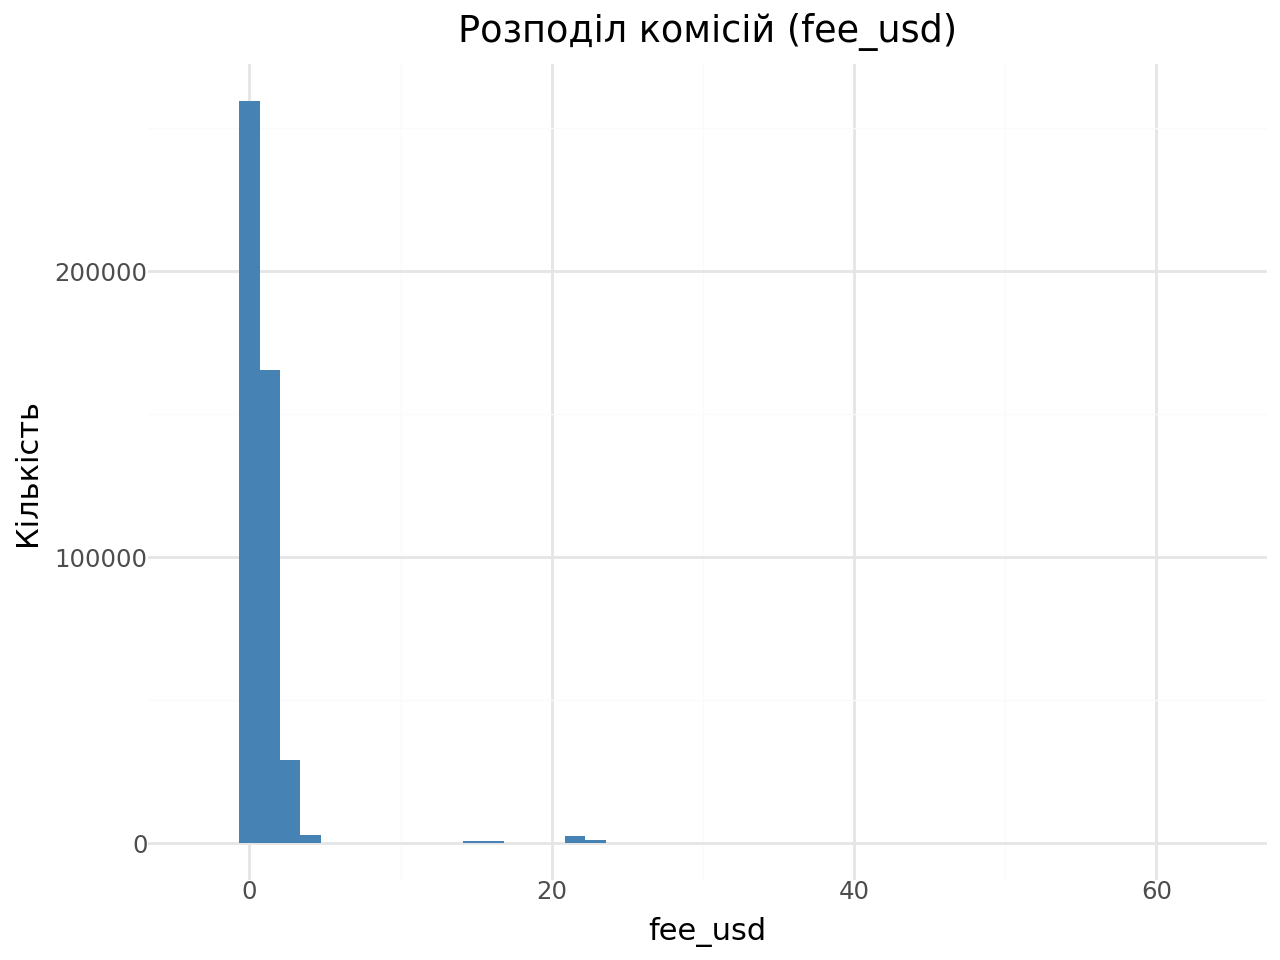

In [ ]:
(
    ggplot(df, aes(x='fee_usd'))
    + geom_histogram(bins=50, fill='steelblue')
    + labs(title='Розподіл комісій (fee_usd)', x='fee_usd', y='Кількість')
    + theme_minimal()
)

Розподіл fee_usd правосторонній, більшість комісій це малі частки долара

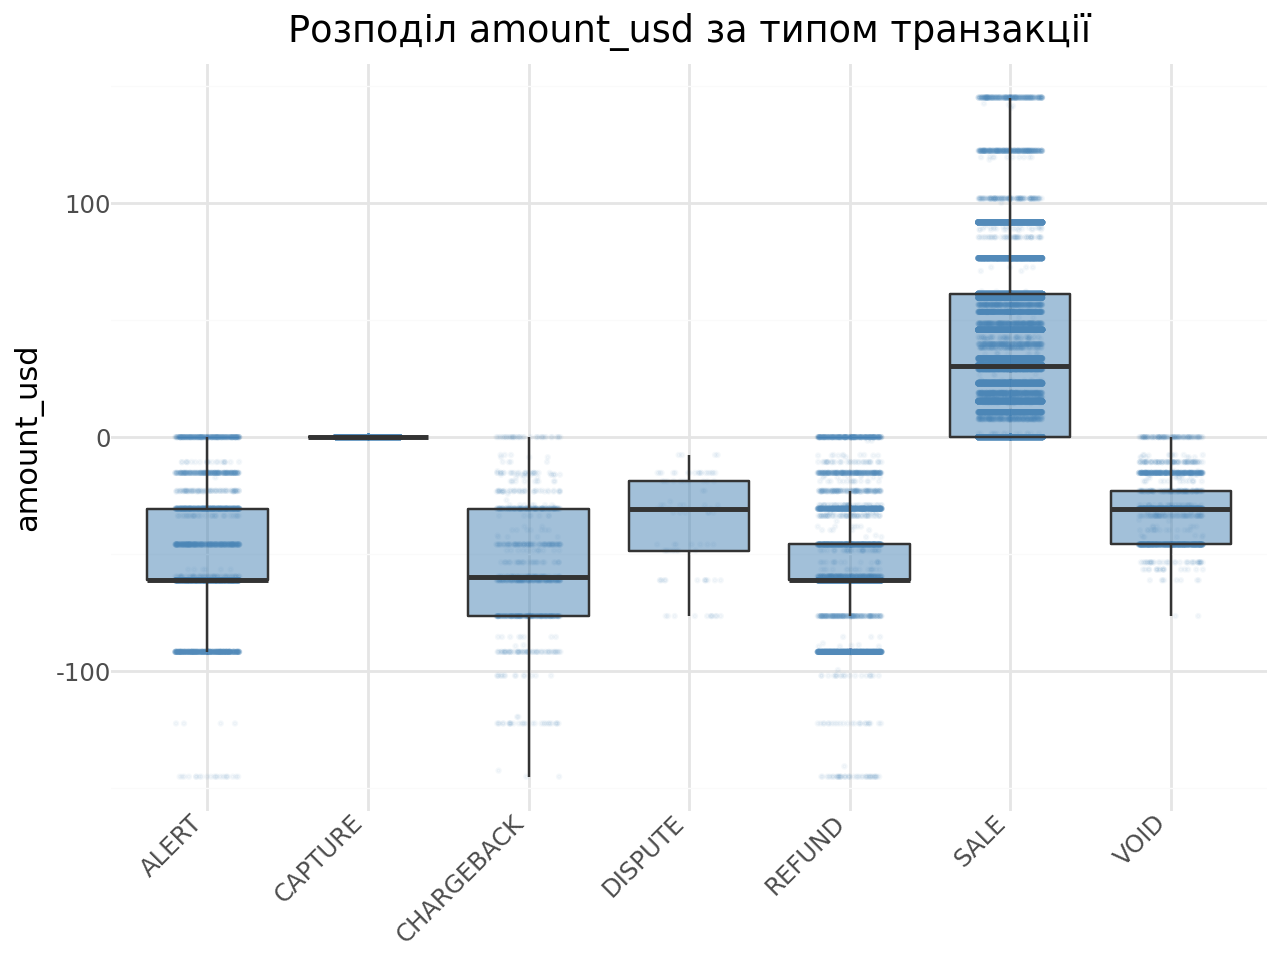

In [ ]:
(
    ggplot(df, aes(x='transaction_type', y='amount_usd'))
    + geom_jitter(width=0.2, alpha=0.05, size=0.3, color='steelblue')
    + geom_boxplot(fill='steelblue', alpha=0.5, outlier_shape='')
    + labs(title='Розподіл amount_usd за типом транзакції', x='', y='amount_usd')
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

SALE має найширший додатний діапазон. CAPTURE стабільно на нулі. Типи повернення коштів (ALERT, CHARGEBACK, REFUND, VOID, DISPUTE) мають схожий негативний діапазон, найбільший розкид  у CHARGEBACK і REFUND.

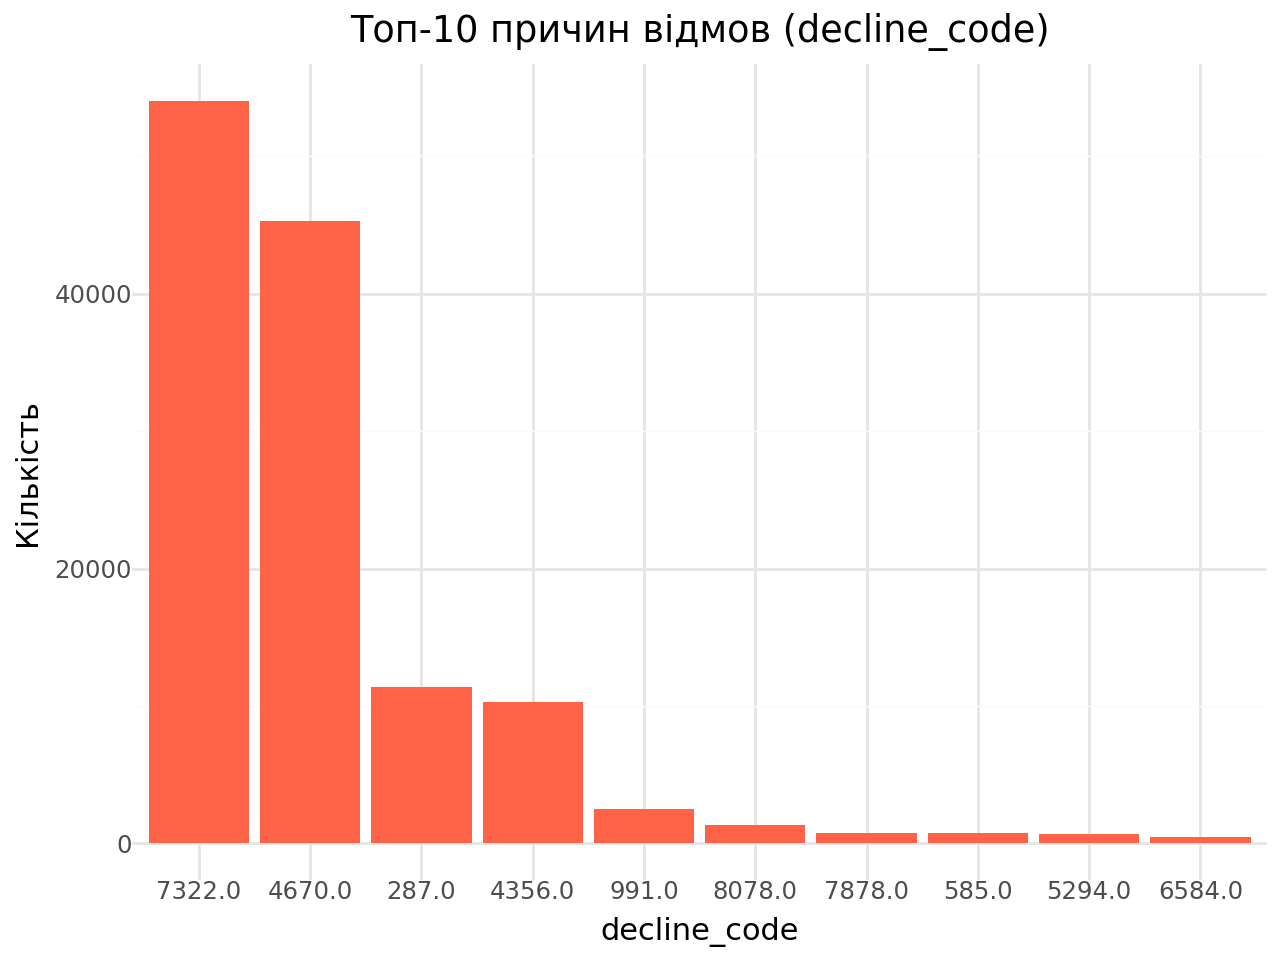

In [ ]:
top_declines = df[df['status']=='DECLINED']['decline_code'].value_counts().head(10).reset_index()
top_declines.columns = ['decline_code', 'count']
top_declines['decline_code'] = top_declines['decline_code'].astype(str)
top_declines['decline_code'] = pd.Categorical(top_declines['decline_code'], categories=top_declines['decline_code'], ordered=True)

(
    ggplot(top_declines, aes(x='decline_code', y='count'))
    + geom_col(fill='tomato')
    + labs(title='Топ-10 причин відмов (decline_code)', x='decline_code', y='Кількість')
    + theme_minimal()
)

Серед причин відмов домінують два коди - 7322 і 4670, решта кодів мають значно нижчу частоту

## 9. Bivariate Analysis

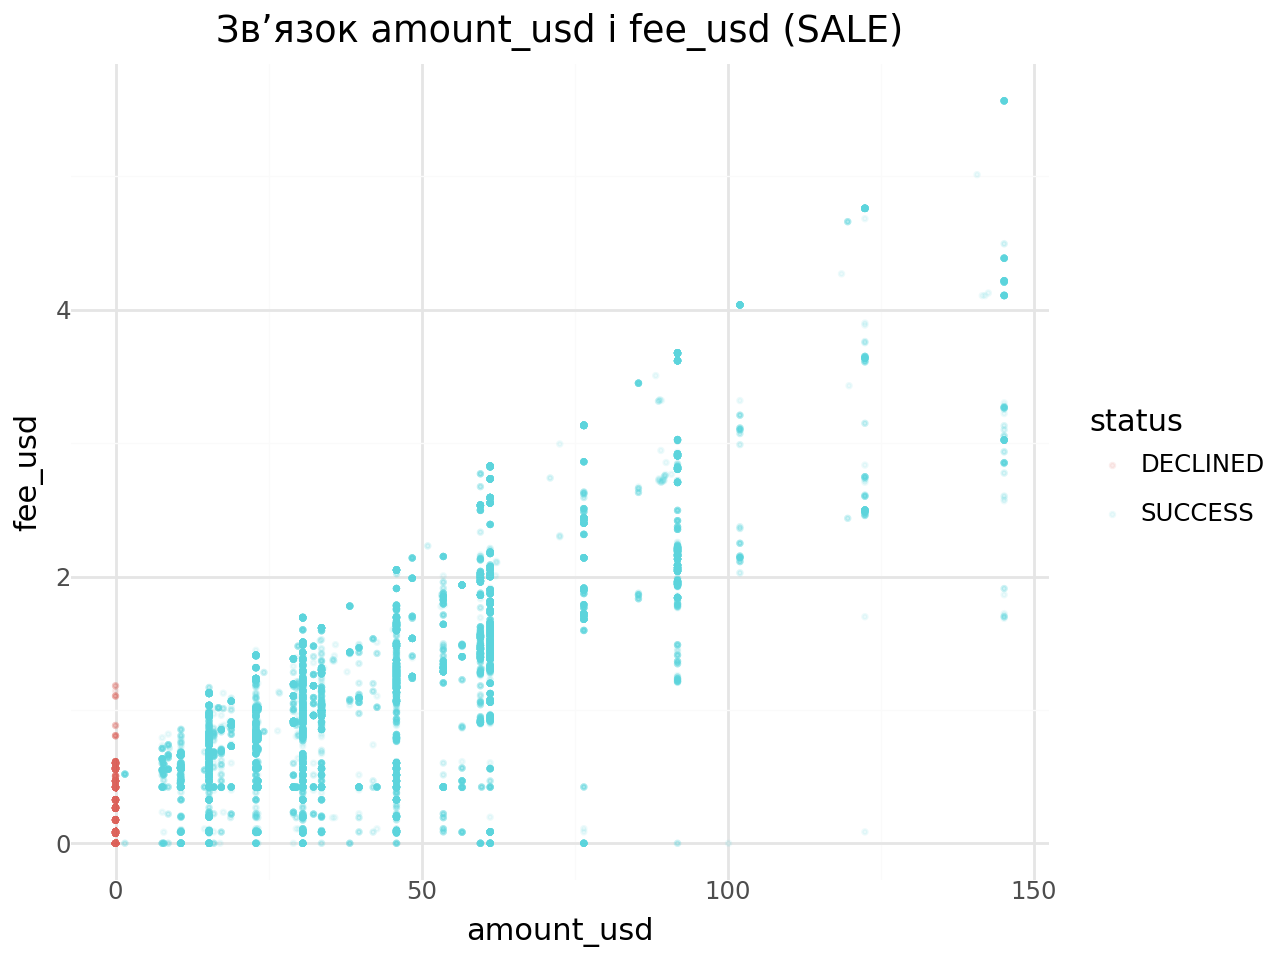

In [ ]:
sale_only = df[df['transaction_type']=='SALE']

(
    ggplot(sale_only, aes(x='amount_usd', y='fee_usd', color='status'))
    + geom_point(alpha=0.1, size=0.5)
    + labs(title='Звʼязок amount_usd і fee_usd (SALE)', x='amount_usd', y='fee_usd')
    + theme_minimal()
)

Комісія зростає майже лінійно (пропорційно) із сумою платежу

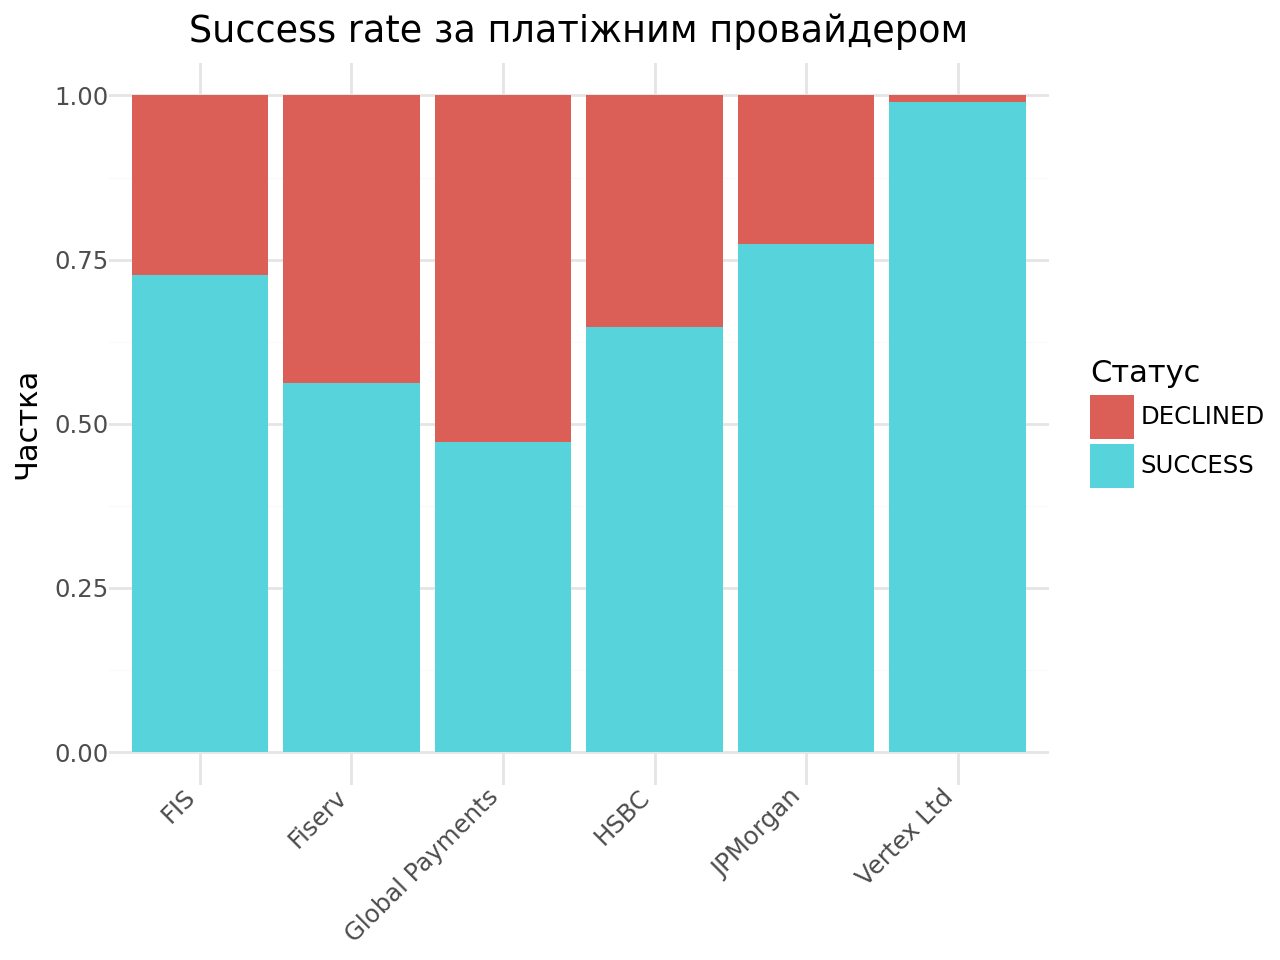

In [ ]:
success_by_psp = df[df['transaction_type']=='SALE'].groupby(['psp_name','status']).size().reset_index(name='count')

(
    ggplot(success_by_psp, aes(x='psp_name', y='count', fill='status'))
    + geom_col(position='fill')
    + labs(title='Success rate за платіжним провайдером', x='', y='Частка', fill='Статус')
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

Виявлено суттєву різницю в success rate між платіжними провайдерами. Vertex Ltd має найкращий показник, коли Global Payments найгірший

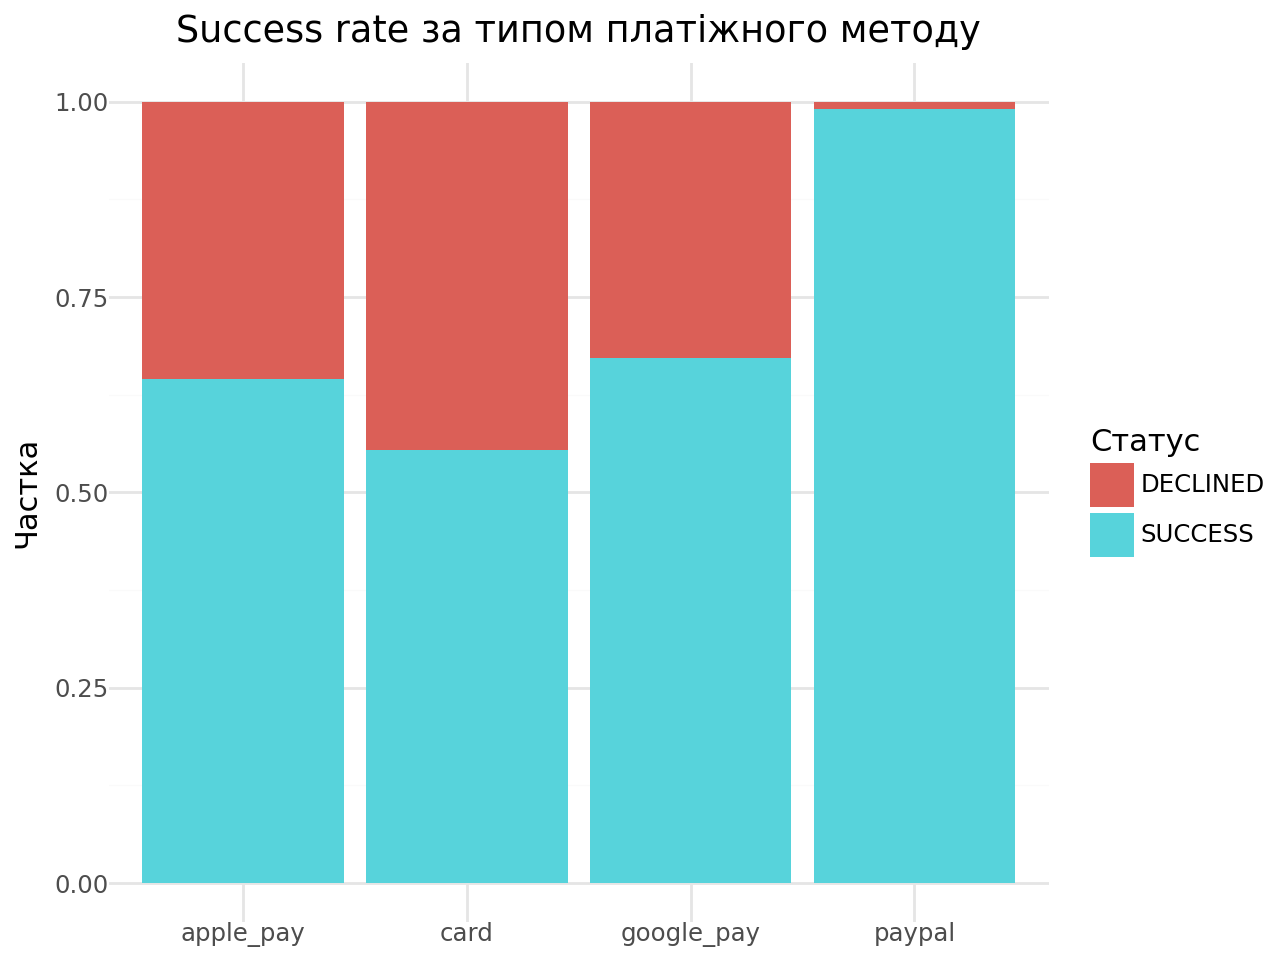

In [ ]:
success_by_method = df[df['transaction_type']=='SALE'].groupby(['payment_method_type','status']).size().reset_index(name='count')

(
    ggplot(success_by_method, aes(x='payment_method_type', y='count', fill='status'))
    + geom_col(position='fill')
    + labs(title='Success rate за типом платіжного методу', x='', y='Частка', fill='Статус')
    + theme_minimal()
)

Success rate суттєво відрізняється й за типом платіжного методу: PayPal демонструє майже ідеальний результат, тоді як звичайні картки (card) мають найнижчий success rate

## Висновок

Усі виявлені пропуски логічно пояснюються природою транзакцій і не є помилками введення даних. `reference_transaction_id` заповнений лише для adjustment-транзакцій (SALE ні на що не посилається), `decline_code` є лише для DECLINED, `card_brand/type/level` заповнення залежать від payment_method_type (PayPal завжди без карткових даних).

Єдиний нюанс: на відміну від user_id (пропуски лише в ALERT/REFUND/CHARGEBACK), пропуски plan_id зачіпають і SALE. Тобто частина реальних платежів не має вказаного тарифного плану. Це не критично для подальшого аналізу, але варто врахувати як особливість даних